In [1]:
import os
while not os.path.isdir('.git'):
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

# Random Poisson inputs

In [2]:
idxs = np.arange(0, 20)

In [3]:
conditions = {
    "No TI": "random_poisson/5/noTI_0.1",
    "5 Hz": "random_poisson/5/1000_5_0.9_0.1",
    "130 Hz": "random_poisson/5/1000_130_0.9_0.1",
    "0 Hz": "random_poisson/5/1000_0_0.32_0.1"
}

colors = {
    "No TI": "tab:blue",
    "5 Hz": "tab:orange",
    "130 Hz": "tab:green",
    "0 Hz": "tab:red"
}

project = "temporal-interference-1"

## Data in a single run

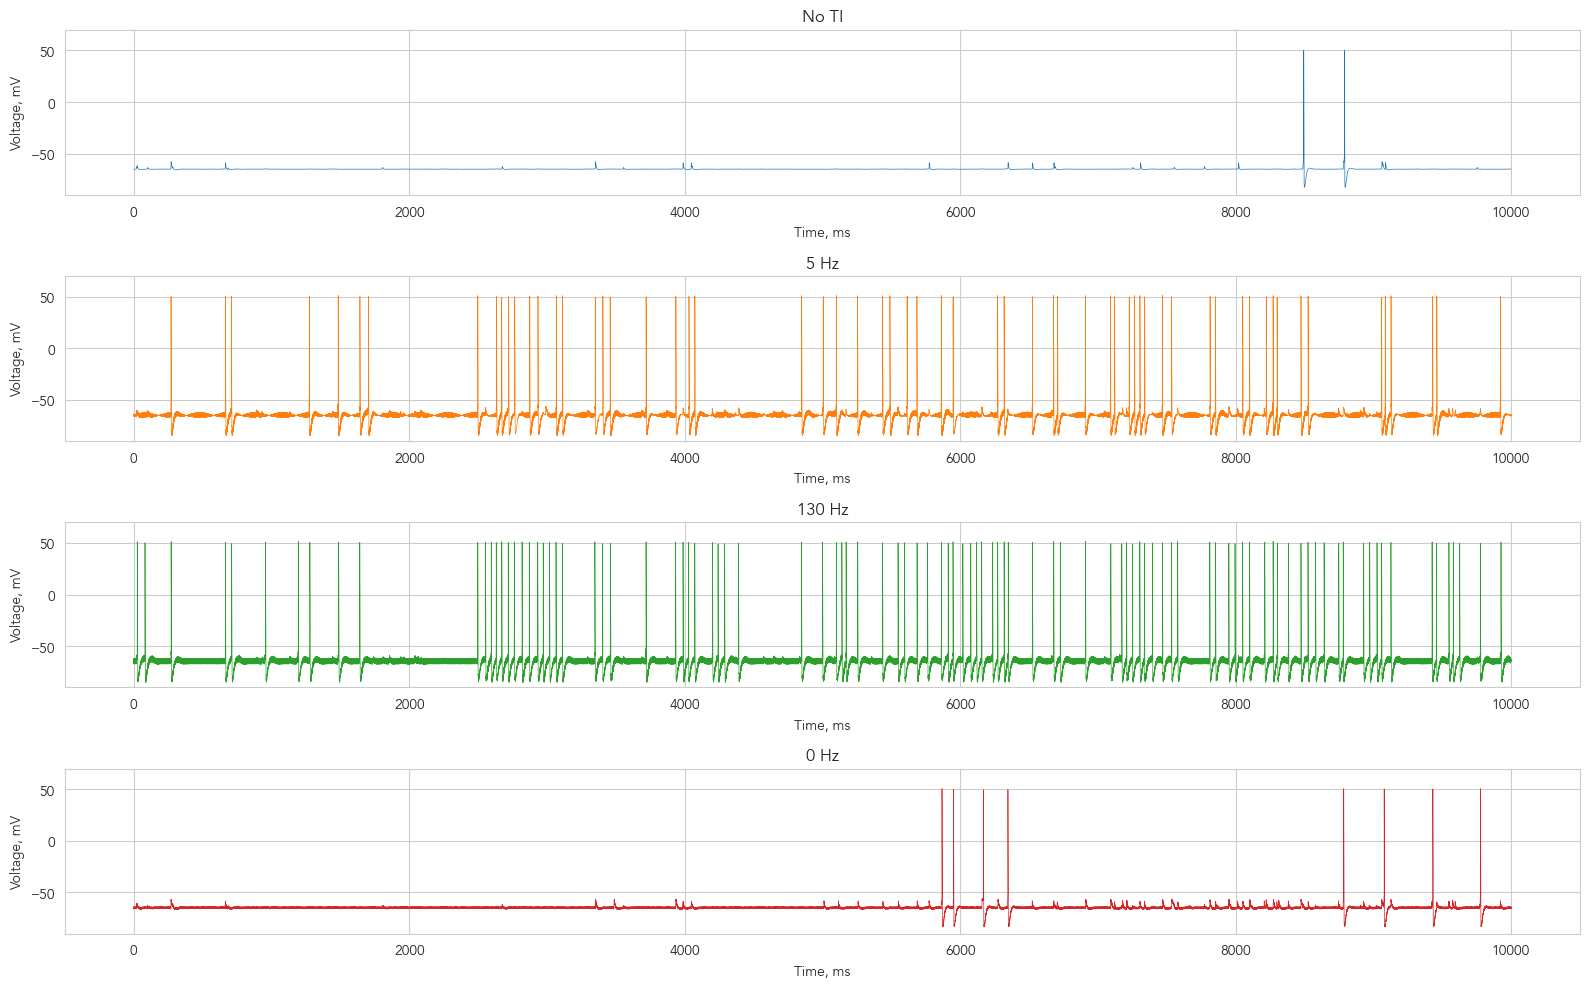

In [4]:
fig, axs = plt.subplots(nrows = len(conditions), ncols = 1, figsize = (16, 2.5 * len(conditions)))

idx = 0

for condition, ax in zip(conditions.keys(), axs):
    filename = conditions[condition]
    color = colors[condition]

    voltage = pd.read_csv(f"output/{project}/{idx}/{filename}/voltage.csv")

    ax.plot(
        voltage.Time,
        voltage.Voltage,
        linewidth = 0.5,
        color = color
    )

    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Voltage, mV")
    ax.set_ylim(-90, 70)

    ax.set_title(condition)

fig.tight_layout()
plt.show()

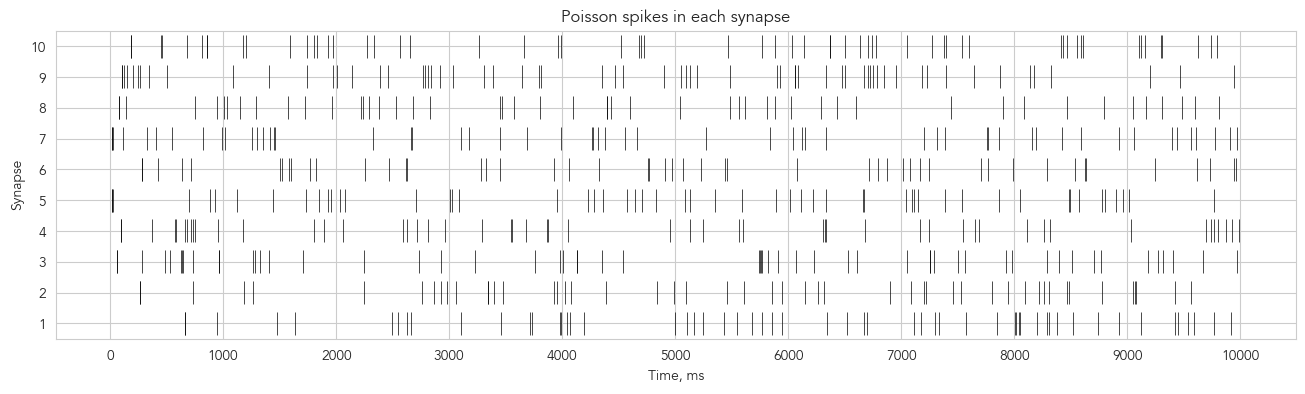

In [5]:
spike_times = pd.read_csv(f"output/{project}/{idx}/{conditions['No TI']}/synapse_stimuli.csv", header=None)
spike_times = spike_times.fillna('').values.tolist()
spike_times = [[x for x in row if x != ""] for row in spike_times]

plt.figure(figsize = (16, 4))

for i, spikes in enumerate(spike_times):
    plt.eventplot(spikes, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

plt.ylim(0.5, 10.5)
plt.ylabel("Synapse")
plt.yticks(np.arange(1, 11, 1))

plt.xlabel("Time, ms")
plt.xticks(np.arange(0, 10_000 + 1000, 1000))

plt.title("Poisson spikes in each synapse")
plt.show()

In [6]:
def expand_time(original, max_time = 10_000):
    original["Time"] = (original["Time"] / 0.025).round() * 0.025
    original = original.sort_values("Time")

    new_time = np.arange(0, max_time + 0.025, 0.025)

    expanded = pd.DataFrame({ "Time": new_time })
    expanded = pd.merge_asof(expanded, original, on = "Time", direction = "backward")

    return expanded

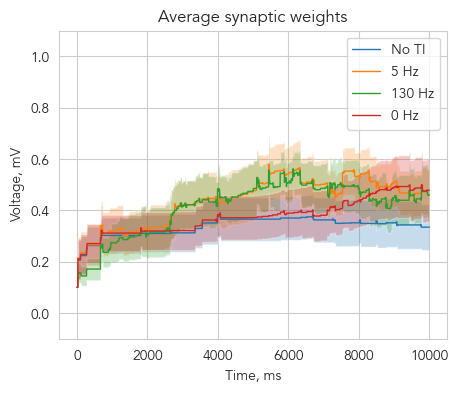

In [7]:
plt.figure(figsize = (5, 4))

for condition in conditions.keys():
    filename = conditions[condition]
    color = colors[condition]

    weights = pd.read_csv(f"output/{project}/{idx}/{filename}/synapse_weights.csv")
    weights = expand_time(weights)
    time = weights.Time
    weights = np.array([ weights[f"Synapse{i}"] for i in range(0, 10) ])

    mean = weights.mean(axis = 0)
    error = weights.std(axis = 0) / np.sqrt(weights.shape[0])

    plt.plot(
        time,
        mean,
        linewidth = 1,
        label = condition
    )
    plt.fill_between(
        time, mean - error, mean + error,
        alpha = 0.25
    )

    plt.xlabel("Time, ms")
    plt.ylabel("Voltage, mV")
    plt.ylim(-0.1, 1.1)

    plt.title("Average synaptic weights")

plt.legend()

fig.tight_layout()
plt.show()

## Data in 20 runs

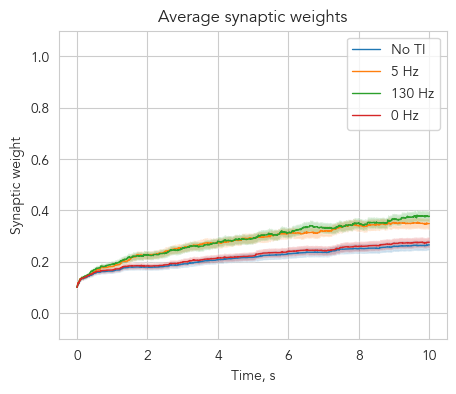

In [8]:
plt.figure(figsize = (5, 4))

for condition in conditions.keys():
    filename = conditions[condition]
    color = colors[condition]

    weights = []
    time = []
    
    for idx in idxs:
        synapse_weights = pd.read_csv(f"output/{project}/{idx}/{filename}/synapse_weights.csv")
        synapse_weights = expand_time(synapse_weights)
        time = synapse_weights.Time / 1000
        
        synapse_weights = np.array([ synapse_weights[f"Synapse{i}"] for i in range(0, 10) ])
        weights.append(synapse_weights)

    weights = np.concatenate(weights)

    mean = weights.mean(axis = 0)
    error = weights.std(axis = 0)  / np.sqrt(weights.shape[0])

    plt.plot(
        time,
        mean,
        linewidth = 1,
        label = condition
    )
    plt.fill_between(
        time, mean - error, mean + error,
        alpha = 0.25
    )

    plt.xlabel("Time, s")
    plt.ylabel("Synaptic weight")
    plt.ylim(-0.1, 1.1)

    plt.title("Average synaptic weights")

plt.legend()
plt.grid(True)

fig.tight_layout()
plt.show()

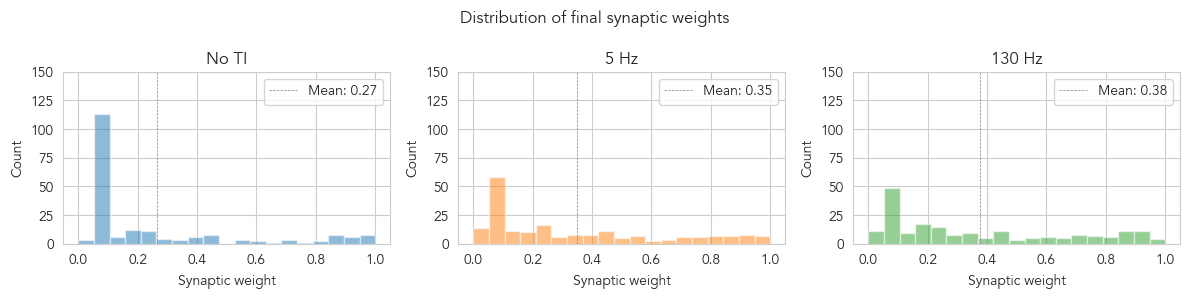

In [9]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3))

for condition, ax in zip(conditions.keys(), axs):
    filename = conditions[condition]
    color = colors[condition]

    weights = []

    for idx in idxs:
        synapse_weights = pd.read_csv(f"output/{project}/{idx}/{filename}/synapse_weights.csv")
        synapse_weights = np.array([ synapse_weights.iloc[-1][f"Synapse{i}"] for i in range(0, 10) ])
        weights.append(synapse_weights)

    weights = np.concatenate(weights)

    bin_edges = np.linspace(0, 1, num = 20)
    ax.hist(weights, bins = bin_edges, alpha = 0.5, color = color)
    ax.axvline(weights.mean(), linewidth = 0.5, color = "gray", linestyle = "--", label = f"Mean: {round(weights.mean(), 2)}")
    ax.set_title(condition)
    ax.set_ylim(0, 150)
    ax.legend()
    ax.set_ylabel("Count")
    ax.set_xlabel("Synaptic weight")

fig.suptitle("Distribution of final synaptic weights")
fig.tight_layout()
plt.show()

## 10 Hz

In [10]:
idxs = np.arange(0, 20)

conditions = {
    "No TI": "random_poisson/10/noTI_0.1",
    "5 Hz": "random_poisson/10/1000_5_0.9_0.1",
    "130 Hz": "random_poisson/10/1000_130_0.9_0.1",
    "0 Hz": "random_poisson/10/1000_0_0.32_0.1",
}

colors = {
    "No TI": "tab:blue",
    "5 Hz": "tab:orange",
    "130 Hz": "tab:green",
    "0 Hz": "tab:red"
}

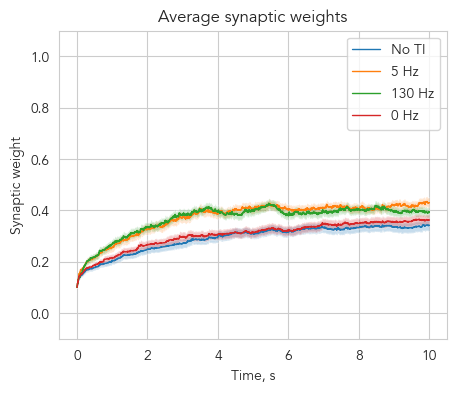

In [11]:
plt.figure(figsize = (5, 4))

for condition in conditions.keys():
    filename = conditions[condition]
    color = colors[condition]

    weights = []
    time = []

    for idx in idxs:
        synapse_weights = pd.read_csv(f"output/{project}/{idx}/{filename}/synapse_weights.csv")
        synapse_weights = expand_time(synapse_weights)
        time = synapse_weights.Time / 1000

        synapse_weights = np.array([ synapse_weights[f"Synapse{i}"] for i in range(0, 10) ])
        weights.append(synapse_weights)

    weights = np.concatenate(weights)

    mean = weights.mean(axis = 0)
    error = weights.std(axis = 0)  / np.sqrt(weights.shape[0])

    plt.plot(
        time,
        mean,
        linewidth = 1,
        label = condition
    )
    plt.fill_between(
        time, mean - error, mean + error,
        alpha = 0.25
    )

    plt.xlabel("Time, s")
    plt.ylabel("Synaptic weight")
    plt.ylim(-0.1, 1.1)

    plt.title("Average synaptic weights")

plt.legend()
plt.grid(True)

fig.tight_layout()
plt.show()

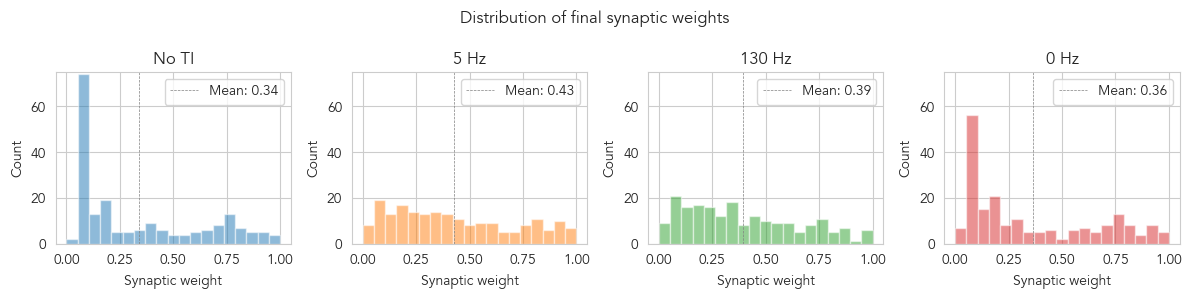

In [12]:
fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize = (12, 3))

for condition, ax in zip(conditions.keys(), axs):
    filename = conditions[condition]
    color = colors[condition]

    weights = []

    for idx in idxs:
        synapse_weights = pd.read_csv(f"output/{project}/{idx}/{filename}/synapse_weights.csv")
        synapse_weights = np.array([ synapse_weights.iloc[-1][f"Synapse{i}"] for i in range(0, 10) ])
        weights.append(synapse_weights)

    weights = np.concatenate(weights)

    bin_edges = np.linspace(0, 1, num = 20)
    ax.hist(weights, bins = bin_edges, alpha = 0.5, color = color)
    ax.axvline(weights.mean(), linewidth = 0.5, color = "gray", linestyle = "--", label = f"Mean: {round(weights.mean(), 2)}")
    ax.set_title(condition)
    ax.set_ylim(0, 75)
    ax.legend()
    ax.set_ylabel("Count")
    ax.set_xlabel("Synaptic weight")

fig.suptitle("Distribution of final synaptic weights")
fig.tight_layout()
plt.show()

## 30 Hz

In [13]:
idxs = np.arange(0, 20)

conditions = {
    "No TI": "random_poisson/30/noTI_0.1",
    "5 Hz": "random_poisson/30/1000_5_0.9_0.1",
    "130 Hz": "random_poisson/30/1000_130_0.9_0.1",
    "0 Hz": "random_poisson/30/1000_0_0.32_0.1",
}

colors = {
    "No TI": "tab:blue",
    "5 Hz": "tab:orange",
    "130 Hz": "tab:green",
    "0 Hz": "tab:red"
}

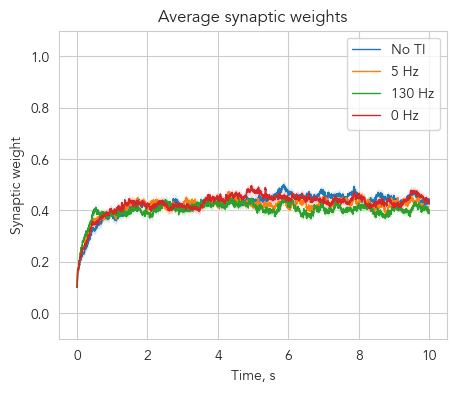

In [14]:
plt.figure(figsize = (5, 4))

for condition in conditions.keys():
    filename = conditions[condition]
    color = colors[condition]

    weights = []
    time = []

    for idx in idxs:
        synapse_weights = pd.read_csv(f"output/{project}/{idx}/{filename}/synapse_weights.csv")
        synapse_weights = expand_time(synapse_weights)
        time = synapse_weights.Time / 1000

        synapse_weights = np.array([ synapse_weights[f"Synapse{i}"] for i in range(0, 10) ])
        weights.append(synapse_weights)

    weights = np.concatenate(weights)

    mean = weights.mean(axis = 0)
    error = weights.std(axis = 0)  / np.sqrt(weights.shape[0])

    plt.plot(
        time,
        mean,
        linewidth = 1,
        label = condition
    )
    plt.fill_between(
        time, mean - error, mean + error,
        alpha = 0.25
    )

    plt.xlabel("Time, s")
    plt.ylabel("Synaptic weight")
    plt.ylim(-0.1, 1.1)

    plt.title("Average synaptic weights")

plt.legend()
plt.grid(True)

fig.tight_layout()
plt.show()

# Comparative analysis of different frequencies

In [15]:
from scipy.stats import ks_2samp
import itertools
from matplotlib.lines import Line2D
import os
from statsmodels.stats.multitest import multipletests

In [16]:
# frequencies = [5, 10, 15, 20, 25, 30]
frequencies = np.arange(1, 31)

idxs = np.arange(0, 20)

colors = {
    "No TI": "tab:blue",
    "0 Hz TI": "tab:red",
    "5 Hz TI": "tab:orange",
    "130 Hz TI": "tab:green"
}

In [23]:
results = []

for frequency in frequencies:
    print(f"Processing frequency {frequency} Hz")
    conditions = {
        "No TI": f"random_poisson/{frequency}/noTI_0.1",
        "5 Hz TI": f"random_poisson/{frequency}/1000_5_0.9_0.1",
        "130 Hz TI": f"random_poisson/{frequency}/1000_130_0.9_0.1",
        "0 Hz TI": f"random_poisson/{frequency}/1000_0_0.32_0.1",
    }
    
    for (condition, filename) in conditions.items():  
        for idx in idxs:
            weight_file = f"output/{project}/{idx}/{filename}/synapse_weights.csv"
            if not os.path.exists(weight_file):
                # print("Does not exist")
                continue
            
            synapse_weights = pd.read_csv(weight_file, index_col = 0)
            synapse_weights = expand_time(synapse_weights)
            final_weights = synapse_weights.tail(1000).drop(columns = ["Time"]).mean().to_list()
        
            results.append(pd.DataFrame({
                "Frequency": frequency,
                "Condition": condition,
                "ID": idx,
                "Synapse": np.arange(0, 10),
                "Weight": final_weights
            }))

results = pd.concat(results, ignore_index = True)

Processing frequency 1 Hz
Processing frequency 2 Hz
Processing frequency 3 Hz
Processing frequency 4 Hz
Processing frequency 5 Hz
Processing frequency 6 Hz
Processing frequency 7 Hz
Processing frequency 8 Hz
Processing frequency 9 Hz
Processing frequency 10 Hz
Processing frequency 11 Hz
Processing frequency 12 Hz
Processing frequency 13 Hz
Processing frequency 14 Hz
Processing frequency 15 Hz
Processing frequency 16 Hz
Processing frequency 17 Hz
Processing frequency 18 Hz
Processing frequency 19 Hz
Processing frequency 20 Hz
Processing frequency 21 Hz
Processing frequency 22 Hz
Processing frequency 23 Hz
Processing frequency 24 Hz
Processing frequency 25 Hz
Processing frequency 26 Hz
Processing frequency 27 Hz
Processing frequency 28 Hz
Processing frequency 29 Hz
Processing frequency 30 Hz


In [24]:
def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"  # not significant

In [25]:
ks_result = []

# Single frequency
for frequency in frequencies:
    # Get weights for all conditions in this frequency
    weights = {}
    for condition in conditions.keys():
        condition_res = results[ (results.Condition == condition) & (results.Frequency == frequency) ].Weight.to_numpy()
        weights[condition] = condition_res
        
    if any([ len(w) == 0 for w in weights.values() ]):
        print(f"Not enough data points for frequency {frequency}")
        continue

    # Perform statistical testing between all conditions
    for (cond1, cond2) in itertools.combinations(conditions.keys(), 2):
        res = ks_2samp(weights[cond1], weights[cond2])

        ks_result.append(pd.DataFrame({
            "Frequency": [frequency],
            "Condition1": [cond1],
            "Condition2": [cond2],
            "Pvalue": [res.pvalue],
            "Statistic": [res.statistic * res.statistic_sign],
            "Star": [p_to_star(res.pvalue)]
        }))
    
# Concatenate all test results
ks_result = pd.concat(ks_result, ignore_index = True)

In [35]:
_, ks_result["Qvalue"], _, _ = multipletests(ks_result.Pvalue, alpha = 0.05, method = "fdr_bh")

In [36]:
ks_result

,Frequency,Condition1,Condition2,Pvalue,Statistic,Star,Qvalue
0,1,No TI,5 Hz TI,0.087838,0.125,ns,0.213661
1,1,No TI,130 Hz TI,0.006094,0.170,**,0.023848
2,1,No TI,0 Hz TI,0.999992,0.030,ns,1.000000
3,1,5 Hz TI,130 Hz TI,0.865527,0.060,ns,0.932903
4,1,5 Hz TI,0 Hz TI,0.142075,-0.115,ns,0.300864
...,...,...,...,...,...,...,...
175,30,No TI,130 Hz TI,0.006094,-0.170,**,0.023848
176,30,No TI,0 Hz TI,0.328115,-0.095,ns,0.509145
177,30,5 Hz TI,130 Hz TI,0.712582,0.070,ns,0.838332
178,30,5 Hz TI,0 Hz TI,0.328115,0.095,ns,0.509145


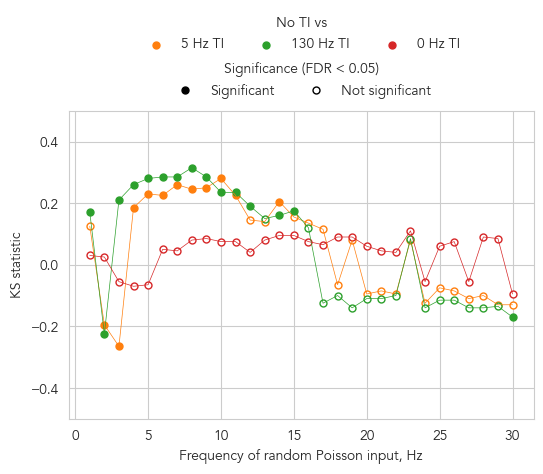

In [38]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (6, 4))

for condition in ["5 Hz TI", "130 Hz TI", "0 Hz TI"]:
    ks_plot = ks_result[(ks_result.Condition1 == "No TI") & (ks_result.Condition2 == condition)]

    sig = ks_plot[ks_plot.Qvalue < 0.05]
    nonsig = ks_plot[ks_plot.Qvalue >= 0.05]
    
    ax.plot(
        ks_plot.Frequency,
        ks_plot.Statistic,
        color = colors[condition],
        linewidth = 0.5
    )

    ax.scatter(
        sig.Frequency,
        sig.Statistic,
        color = colors[condition],
        label = condition,
        s = 25
    )

    ax.scatter(
        nonsig.Frequency,
        nonsig.Statistic,
        facecolors = "white",
        edgecolors = colors[condition],
        s = 25
    )

legend_elements = [
    Line2D([0], [0], marker = "o", color = "k", markerfacecolor = "k", markersize = 5, linestyle = "None", label = "Significant"),
    Line2D([0], [0], marker = "o", color = "k", markerfacecolor = "none", markersize = 5, linestyle = "None", label = "Not significant"),
]

ax.set_xlabel("Frequency of random Poisson input, Hz")
ax.set_ylabel("KS statistic")
ax.set_ylim(-0.5, 0.5)

legend = ax.legend(
    title = "Significance (FDR < 0.05)",
    handles = legend_elements,
    loc = "upper center",
    ncols = 2,
    frameon = False,
    bbox_to_anchor = (0.5, 1.2)
)

plt.gca().add_artist(legend)

ax.legend(
    title = "No TI vs",
    frameon = False,
    loc = "upper center",
    ncols = 3,
    bbox_to_anchor = (0.5, 1.35)
)

plt.show()

KS statistic = largest difference between the two distributions; positive values indicate that the TI condition is larger, negative values indicate that the no TI condition is higher; significance = how likely are the data points to come from the same distribution?